# RoadGuard CV: Road Hazard Classifier

## Milestone 1: Data Collection and Baseline Classifier

This project is an autonomous systems / computer vision project. The goal is to classify road hazards into two classes:

- Potholes
- Road debris / road objects

The system can be used in smart mobility applications, where a camera on a vehicle captures road images and the model predicts whether the image contains a pothole or debris.

In [47]:
import os

os.makedirs("dataset/pothole", exist_ok=True)
os.makedirs("dataset/debris", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


## Dataset

The dataset is divided into two folders:

- `dataset/pothole`: contains pothole road images
- `dataset/debris`: contains road debris or road object images

Each image is resized to 128×128 pixels and converted to grayscale before feature extraction.

In [48]:
data = []
labels = []

classes = {
    "pothole": 0,
    "debris": 1
}

for class_name, label in classes.items():
    folder = f"dataset/{class_name}"

    for file_name in os.listdir(folder):
        image_path = os.path.join(folder, file_name)

        image = cv2.imread(image_path)

        if image is None:
            continue

        image = cv2.resize(image, (128, 128))
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        data.append(gray_image)
        labels.append(label)

print("Number of images loaded:", len(data))
print("Number of labels:", len(labels))

Number of images loaded: 10
Number of labels: 10


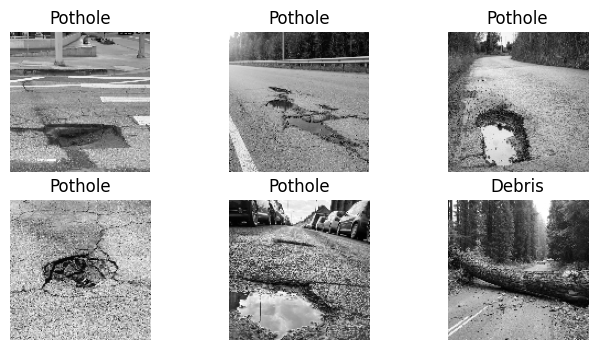

In [49]:
plt.figure(figsize=(8, 4))

for i in range(min(6, len(data))):
    plt.subplot(2, 3, i + 1)
    plt.imshow(data[i], cmap="gray")
    plt.axis("off")
    plt.title("Pothole" if labels[i] == 0 else "Debris")

plt.show()

## HOG Feature Extraction

HOG stands for Histogram of Oriented Gradients.

It is used to extract shape and edge features from images. This is useful because potholes and debris have different edge patterns:

- Potholes usually have rounded or crater-like edges.
- Debris usually has sharper and more irregular edges.

The extracted HOG features are then used as input to the SVM classifier.

In [50]:
features = []

for image in data:
    hog_features = hog(
        image,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    features.append(hog_features)

X = np.array(features)
y = np.array(labels)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

Feature matrix shape: (10, 1764)
Labels shape: (10,)


## SVM Classifier

SVM stands for Support Vector Machine.

It is a machine learning model used for classification. In this project, the SVM learns the difference between pothole images and debris images based on their HOG features.

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = SVC(kernel="rbf", probability=True)
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [52]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print()
print(classification_report(y_test, y_pred, target_names=["Pothole", "Debris"]))

Accuracy: 1.0

              precision    recall  f1-score   support

     Pothole       1.00      1.00      1.00         1
      Debris       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



## Conclusion

In this milestone, a baseline road hazard classifier was created using HOG feature extraction and an SVM classifier.

The system classifies road images into two categories: potholes and road debris. The images were preprocessed, converted to grayscale, resized to 128×128 pixels, and then transformed into HOG feature vectors.

This baseline model can be improved in future milestones by using a larger dataset, better image cleaning, and deep learning models such as CNNs.

In [53]:
!pip install scikit-image scikit-learn opencv-python matplotlib

In [54]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score